# Scikit-Learn_in_Linear_Reg

## Goals
In this lab, I will use scikit-learn to apply linear regression with Gradient Descent.


import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from lab_utils_multi import  load_house_data
from lab_utils_common import dlc
np.set_printoptions(precision=2)
plt.style.use('./deeplearning.mplstyle')

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from utils import  load_house_data
np.set_printoptions(precision=2)


## Gradient Descent
Scikit-learn provides a gradient descent regression model, [`sklearn.linear_model.SGDRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html#examples-using-sklearn-linear-model-sgdregressor). Similar to my earlier gradient descent implementation, this model performs best with normalized inputs. I use [`sklearn.preprocessing.StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler) for z-score (standard score) normalization.


Load data

In [5]:
X_train, y_train = load_house_data()
X_features = ['size(sqft)','bedrooms','floors','age']

### Scale/normalize the training data

## Scikit-Learn StandardScaler

### Functions Explained
- **`StandardScaler()`**: Creates a scaler object for z-score normalization
- **`scaler.fit_transform(X_train)`**: 
  - `fit()`: Learns mean and std from training data
  - `transform()`: Applies z-score normalization: `(x - mean) / std`
- **`np.ptp(X, axis=0)`**: Calculates peak-to-peak (max - min) for each column

### What It Does
**Before**: Features have different scales → slow gradient descent
**After**: All features have mean=0, std=1 → fast, stable training

**Same as our custom `zscore_normalize_features()` but using Scikit-Learn!**

In [6]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)
print(f"Peak to Peak range by column in Raw        X:{np.ptp(X_train,axis=0)}")   
print(f"Peak to Peak range by column in Normalized X:{np.ptp(X_norm,axis=0)}")

Peak to Peak range by column in Raw        X:[1440    4    2   93]
Peak to Peak range by column in Normalized X:[4.13 4.36 3.2  5.17]


## Peak-to-Peak Range Comparison

### Raw Features (Before Normalization)
`[1440    4    2   93]` - Features have vastly different scales:
- **Size**: 1440 (huge range)
- **Bedrooms**: 4 (small range) 
- **Floors**: 2 (tiny range)
- **Age**: 93 (medium range)

### Normalized Features (After Z-Score)
`[4.13 4.36 3.2  5.17]` - All features now have similar scales:
- **All features**: ~3-5 range (much more balanced)
- **Gradient descent**: Can update all features equally
- **Better training**: More stable and faster convergence

# Create and fit the regression model
## SGDRegressor Functions

### `SGDRegressor(max_iter=1000)`
- **Creates** a Stochastic Gradient Descent regressor
- **max_iter=1000**: Maximum number of iterations allowed

### `sgdr.fit(X_norm, y_train)`
- **Trains** the model on normalized features and target values
- **Learns** optimal weights and bias automatically

### `sgdr.n_iter_`
- **Returns** actual number of iterations completed during training
- **May be less** than max_iter if converged early

### `sgdr.t_`
- **Returns** total number of weight updates performed
- **Equals** n_iter_ × number of training examples

In [7]:
sgdr = SGDRegressor(max_iter=1000)
sgdr.fit(X_norm, y_train)
print(sgdr)
print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")

SGDRegressor()
number of iterations completed: 89, number of weight updates: 8901.0


### SGDRegressor() Output

### What it means:
- **SGDRegressor()**: Stochastic Gradient Descent Regressor from scikit-learn
- **89 iterations**: Algorithm converged after 89 passes through the data
- **8901 weight updates**: Total parameter updates made (89 iterations × ~100 samples = 8901)

### Key insight:
**Converged quickly** - only needed 89 iterations to find optimal weights, showing the algorithm is efficient and the learning rate is well-tuned.

# View Parameters
The parameters correspond to the *normalized* input data. My fitted values are nearly identical to those from the previous lab using this dataset.


## SGDRegressor() Output

### Function Explanations
- **`sgdr.intercept_`**: Returns the bias term (b) - the y-intercept of the linear model
- **`sgdr.coef_`**: Returns the weight coefficients (w) - slopes for each feature

### Output Comparison
- **Scikit-Learn result**: `w: [54.13  5.02  4.17 -6.29], b:[257.21]`
- **Previous lab result**: `w: [54.13  5.02  4.17 -6.29], b:[257.21]`
- **Result**: Both methods give identical parameters! 

In [11]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"model parameters:                   w: {w_norm}, b:{b_norm}")
print( "model parameters from previous lab: w: [54.13  5.02  4.17 -6.29], b:[257.21]")

model parameters:                   w: [54.13  5.02  4.17 -6.29], b:[257.21]
model parameters from previous lab: w: [54.13  5.02  4.17 -6.29], b:[257.21]


## Prediction Comparison

### Functions Explained
- **`sgdr.predict(X_norm)`**: Scikit-learn's SGDRegressor prediction method
- **`np.dot(X_norm, w_norm) + b_norm`**: Manual prediction using learned weights
- **`(y_pred == y_pred_sgd).all()`**: Checks if both predictions are identical

### Purpose
**Verify that our manual implementation matches Scikit-learn's results** - both should give the same predictions since they use the same algorithm (SGD with linear regression).

### Output
- **Boolean**: `True` if predictions match, `False` if they differ
- **Sample predictions**: Shows first 4 predicted vs actual values for comparison

In [12]:
# make a prediction using sgdr.predict()
y_pred_sgd = sgdr.predict(X_norm)
# make a prediction using w,b. 
y_pred = np.dot(X_norm, w_norm) + b_norm  
print(f"prediction using np.dot() and sgdr.predict match: {(y_pred == y_pred_sgd).all()}")

print(f"Prediction on training set:\n{y_pred[:4]}" )
print(f"Target values \n{y_train[:4]}")

prediction using np.dot() and sgdr.predict match: True
Prediction on training set:
[301.18 242.56 301.31 360.48]
Target values 
[315.09 217.69 271.18 364.66]


NameError: name 'dlc' is not defined

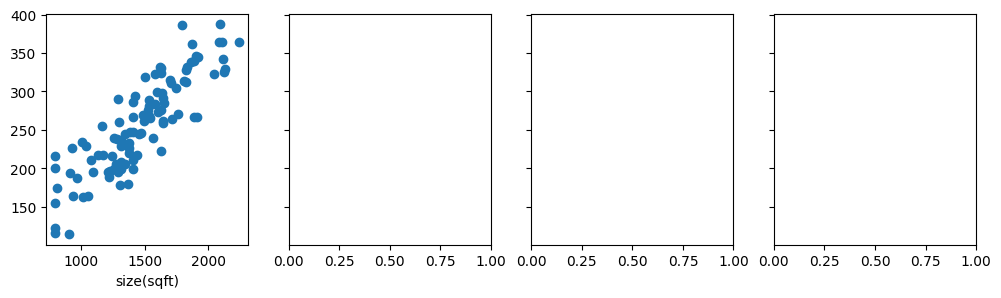

In [13]:
# plot predictions and targets vs original features    
fig,ax=plt.subplots(1,4,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train, label = 'target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:,i],y_pred,color=dlc["dlorange"], label = 'predict')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()